## Introduction

### Background

Gaze behavior in primates consists of two fundamental modes—gaze fixation and gaze shifts—each supported by distinct sensorimotor mechanisms. Gaze fixation refers to periods when the eyes maintain a stable visual line of sight, even when the head moves. This stability is primarily achieved through the vestibulo-ocular reflex (VOR), in which head rotation triggers a compensatory eye movement in the opposite direction. The result is a characteristic negative correlation between eye and head velocity: as the head drifts slightly, the eye counter-rotates to keep gaze steady. Fixation therefore provides a clean physiological signature of VOR function in freely moving animals.

In contrast, gaze shifts are rapid reorientations of gaze used to bring new objects of interest onto the fovea. In natural behavior—especially in freely moving marmosets—gaze shifts can be produced by the eyes alone or by coordinated contributions of the eyes and head. These movements fall into two main categories:

Type 1 gaze shifts (eye-only), where the eye produces a sharp, saccade-like velocity peak while the head contributes minimally.

Type 2 gaze shifts (combined eye + head), in which both effectors generate meaningful movement. In these events, the eye typically peaks first, and the head reaches its peak later. As the head slows with a long tail, the eye often reverses direction briefly to re-engage the VOR and stabilize final gaze direction.

These dynamics were illustrated vividly in the original dataset and figures (e.g., Figure 6C and 6D), where fixation shows clean VOR anti-correlation, and gaze shifts show distinct temporal coordination patterns. Such patterns represent the natural biomechanics and neural control principles of primate gaze.

Understanding how these two modes—fixation and gaze shift—interact is fundamental to modeling naturalistic eye–head coordination. In this project, the simulation aims to reproduce these biological signatures, using real marmoset data to constrain the kinematics of both fixation and gaze-shift events. The simulation’s success is evaluated by comparing real and synthetic events on peak velocities, durations, coordination timing, and distributional properties.

### Justification for choice of study

I choose a recent paper from my advisor. I will try to replicate experiment in the figure 6 (especially the figure 6C). Figure 6C is part of a study analyzing gaze behavior in freely moving marmosets wearing the CEREBRO head-mounted eye-tracking system. The experiment involves recording marmosets as they freely explore a large open arena (200 cm × 100 cm × 240 cm). The goal of the experiment is to test the relations of eye movement and head movement. During this exploration, the system simultaneously records. CERBRO in this paper is an effective device that can collect eye-tracking data in free-moving marmoset. In my project, I will also use CERBRO and record the data from free-moving systems and research questions of specific tasks (e.g. social interactions).My research interest stands on natural visual behavior of the marmoset, so get to familiar with the eye-tracking data collected by this device is helpful for me to do research. 


### Links

Project repository (on Github): https://github.com/Luyiheng-19/singh2025active/tree/main

Original paper (as hosted in your repo): https://github.com/Luyiheng-19/singh2025active/blob/main/original_paper/2025_SinghEtAl.pdf

### Hypotheses
H1. Fixation VOR Behavior
During fixation periods (non–gaze-shift epochs), the simulated eye and head velocity should show a negative correlation, reflecting the vestibulo-ocular reflex (VOR).
The simulation should not produce strong positive or negative correlations during gaze-shift periods.
This pattern should resemble the VOR structure shown in Figure 6C of the original paper.

H2. Presence of Two Distinct Gaze-Shift Events
The simulated 10-second interval should contain two clear gaze-shift events, matching the example shown in Figure 6D (bottom) of the original paper.

H3. Event 1: Eye-Dominated Gaze Shift
In the first simulated event, the gaze velocity profile should primarily follow the eye velocity, with minimal contribution from head movement.
This corresponds to an eye-only (Type 1) gaze shift.

H4. Event 2: Combined Head + Eye Gaze Shift with VOR Re-engagement
In the second simulated event, both eye and head velocities should change, reflecting a combined (Type 2) shift. This event should display the characteristic temporal structure:
Eye velocity peaks first
Head velocity peaks later
As head velocity decays slowly (long tail),
Eye velocity reverses sign (crosses zero) to re-engage the VOR and stabilize gaze
Thus, the simulated traces should show the pattern:
eye peak → delayed head peak → eye reverses direction (if head remains positive)
matching the coordination structure in the original dataset.


H5. Matched Kinematic Statistics
For both simulated events, peak velocity and event duration should be similar to the corresponding events detected in the random 10-second real interval.


## Methods

### Description of the steps required to reproduce the results

The preprocessed data(it is on https://datadryad.org/dataset/doi:10.5061/dryad.8gtht76xb) is avalible. Here is the key steps


(1) randomly choose 10s experiment and plot the figure 6C
(2) detect the 2 types of key event of gaze shift and visualize the data in this 10s
(3) simulate the data
(4) visualize and compare the simulated data and real data, reproduce figure 6D below
(5) calculate relevant paprameters and compare to real data
(6) reproduce figure 6C in simulated data




### Differences from original study


The origin study is an engnieering study, and the origin figure only visualize some experiment result. I'll try to simulate the random eye-tracking data information.


### Details


a. Comfirmatory Focus: simulate the head velocity and eye velocity data that have features like figure 6. They should negative related in the fixation event (to show the VOR), and not high postive related in gaze-shift event. And it shoud have two kind of gaze shift events. That means they should replicate the result of figure 6C and figure 6D below no matter what kind of interval is chosen(the interval's feature should follow the figure6C). Also, the simulated data should have simliar key feature of the 10s interval that we choose(with no significant difference). 

VOR (Vestibulo-Ocular Reflex) is a reflex that makes your eyes automatically move in the opposite direction of your head movement, so that your vision stays stable even when you are moving.

Key simulation 

In fixation:

Althouth in fixation, the head and eye still move slowly. We can simulated as a sine process beacuse it has two directions and mean is zero. And it changes slowly.

Vhead(t) = A Sin(2pi * ft) + nosie
Veye(t) = -r * Vhead(t) + nosie 

In gaze shift.

each eye or head movement (a saccade or head turn) is represented as a half-sine pulse  Using r to show VOR. Use noise, which is for simulate real world data. The nosie's distribution is N(0, std)


f: Frequency

-r: regression slope r, represent the correlation

noise: can estimate by the varience of data


In gaze shift:

in this condition, when the marmosets gaze shifts, it is obviously increase	the value of both velocities, so I give them a pulse, wich represnts the gaze shift.

Vevent_head(t) = Apeak_head Sin(pi * (t-t0/Dhead)) (when the event happens, time:t0, t is only avalible from t0 to t0+ Dhead)

Vevent_eye(t) = Apeak_eye Sin(pi * (t-t0/Deye)) (When the event happens , time:t0, t is only avalible from t0 to t0+ Deye)

So the t is the real time, and when t goes t+D, the event finish. D is the duration of shift.

So the real velcoty is 

Vhead_real(t) = Vhead(t) + Vhead_event(t)
Veye_real(t) = Veye(t) + Veye_event(t)

The parpameter will be calculated by the chosen interval.


### Measure of success

The outcome measure for the success or failure of your reproduction and how this outcome will be computed. There data should have this points:

1. show negative relation when fixation, without high positive correlation in gaze shift, as figure 6C, Show the VOR,
2. should have two gaze shift events, as Figure6 D below.
3. The first event is the gaze velocity profile follows the eye.
4. The second is that both of two velocities change\n", In this event, eye velocity peaks .earlier than head velocity; then as head velocity decays with a long tail, the eye velocity reverses sign to re-engage VOR and stabilize gaze. Traces should show: eye peak first → later head peak → eye crosses zero and goes negative (if head stays positive) to cancel residual head motion.  
5. the duration and some traits in event is similar as the chosen 10s interval.


### Key questions 


1. What assumptions does your generative model make about participant behavior, and which aspects of the real experiment does it simplify or omit?
My generative model assumes that marmoset gaze behavior can be represented using a small set of kinematic rules derived from the real dataset. Specifically, it assumes:

Assumptions about behavior:
Fixation periods are governed by the VOR, which produces a negative correlation between head and eye velocity.

Two types of gaze shifts account for most natural reorientations:
Type 1: eye-dominated, short-latency saccade-like events
Type 2: combined head+eye events with delayed head peak and VOR re-engagement
Peak velocities and event durations follow approximately normal distributions derived from the 10-s empirical sample.

Noise during fixation follows a Gaussian distribution matched to the variance of real fixation traces.

Head and eye movements can be modeled using simple sine or half-sine pulses, which capture the general profile of gaze-shift kinematics.

Simplifications / omitted complexities
The model omits many naturalistic features of real behavior:

No variability in sensory or motor delays other than fixed offsets (e.g., delayed head peak).
No biomechanics of muscle dynamics, inertia, or nonlinear velocity–duration dependencies.
No trial-to-trial adaptation, intention, or behavioral context (attention, motivation, targets).
Only two gaze-shift events are simulated, whereas real behavior includes many micro-movements, aborted shifts, and multi-phase shifts.

No 3D head or eye rotations or torsional components—only horizontal (yaw and horizontal eye).
Environmental constraints (e.g., cage walls, visual targets, distraction) are ignored.
The model treats behavior as stationary, while real movement statistics vary across time and context.

This means the model captures kinematic structure, not the full richness of freely moving behavior.

But it is almost impossible to capture all the variablity of real-world data.

2. Show how your simulated dataset flows through your planned analysis pipeline. Does this recover any mismatches or bugs?

I make many modifications of my planned analysis pipeline, espeicially the simulation code. I've tired lots of time for the event detection. At first I don't differentiate the 2 types event. And I tried lots of thershold of event detection. Finally I decide to the thershold that in the original paper.

In the simulation, I add some random small pulse to fit the real data. There are many pulse below the thershold and can't esily be detected.

In anaylsis, I find nosie is not enough to show the scatter plot

Step 1: Generate simulation
Create time series of head and eye velocity
Insert two gaze-shift events
Add fixation noise
Enforce VOR-like anti-correlation during fixation
Add delays and sign reversal for Event 2

Step 2: Extract kinematic measurements
For each detected event:
peak eye velocity
peak head velocity
event duration
timing offset of peaks
head–eye correlation

Step 3: Real vs. simulated comparisons
t-tests tests on peak velocities/duration
Scatter plots + error bars of real vs. sim peak velocities
Coordination summary (eye-first vs. head-first)



3. Identify one insight your simulation gave you about the strengths or limitations of the original experimental design.

One really important point is that the data in orginal paper is really typical and clear. In many data it can not fully show this pattern. In the original paper, they choices of 10s interval and 200deg/s as the threshold should be more careful

The simulation shows that event-type classification (Type 1 vs. Type 2) is extremely sensitive to threshold settings and noise levels. Even small variations in velocity or noise determine whether an event crosses the “head movement” threshold and changes its category.

Implication
This reveals a limitation in the original experiment:
The classification scheme depends heavily on arbitrary cutoff values, meaning:
Slight noise increases can misclassify events
Very small head movements blur the line between Type 1 and Type 2
Head/eye coordination patterns may appear more discrete than they truly are
My simulation highlights that the original design is strong in capturing natural behavior but weak in defining sharp categorical boundaries.

The conclusion of orginal paper can't explain all the varibilty of data, for example, in real data tehre are many pulse that is smaller than 200deg/s, which represents small gaze shifts slower than the research presented.

4. How would this simulation help you design a follow-up experiment with a similar paradigm?

The simulation clarifies which features of gaze-shift behavior are essential and which features are fragile. For a follow-up experiment, the simulation provides several concrete design improvements:

A. More robust event classification methods

Simulation shows threshold-based classification is brittle.

Future experiments should include:

adaptive thresholds

continuous event metrics (rather than categorical Type 1/2 labels)

supervised classification using real waveform shapes

B. Better temporal alignment tools

Because the simulation exposes how critical timing offsets are, a follow-up experiment should:
record with higher temporal resolution

calibrate head–eye alignment more precisely

reduce clock drift between sensors

C. Control over behavioral state
The simulation demonstrates that VOR and gaze-shift patterns differ sharply.

A future study could:
use controlled perturbations

present visual targets

include conditions with or without expected head movement

D. Testing new hypotheses
The simulation makes it easy to prototype:

different VOR gain conditions

different head-movement profiles

different levels of environmental constraints

This lets the experimenter predict what patterns should appear before running a real study.
Overall, the simulation supports efficient pilot testing, helps identify design flaws, and guides parameter selection for more reliable and interpretable gaze data.

E. New models
My information of the data is limited, but it makes me more intereted that can we successfully predict the gaze velocity (including eye horizontal velocity and head yaw velocity) by a model? 

This should collect more data, their world cemra images, or even their brain activities. I believe tehre is one way to explain fully of their gaze patterns and  variblities. In this event-based simulation model, it can explain some, but not all.



## Results

	
### Data Preparation


Dowlaod the data and load the .mat file. 

Show the dataframe shape and varible name

Chose the freely moving experiment time

Align the time line.

Remove the extreme value.

Show the data

#### Load Relevant Libraries and Functions

numpy, scipy, matplotlib, random

#### Import data

random choose 10s and show figue like figue 6C

calculate the correlation r, ensure in fixation r is below zero, and in gaze shift is not so high


In [2]:
import os

# List all files in current folder
print(os.listdir())


['Untitled1-Copy4.ipynb', 'Untitled1.ipynb', 'Untitled1-Copy2.ipynb', 'Untitled.ipynb', 'Untitled1-Copy5.ipynb', 'Untitled1-Copy1.ipynb', 'Untitled1-Copy3.ipynb', 'README.md', 'Final.ipynb', 'Head_Eye_Body_Movement_Data_VPS_2024.mat', '.ipynb_checkpoints']


In [3]:
from scipy.io import loadmat

data = loadmat('Head_Eye_Body_Movement_Data_VPS_2024.mat')
print(data.keys())



dict_keys(['__header__', '__version__', '__globals__', 'Syncbox', 'eye_deg', 'eye_degV', 'eye_isSac_chair', 'eye_isSac_free', 'eye_time', 'fs_eye', 'fs_opti', 'opti_bodySmoV', 'opti_bodyxyz_smo', 'opti_headrot_smo', 'opti_headuvwSmoV', 'opti_headuvw_smo', 'opti_isHdt', 'opti_isLoc', 'opti_time', 'opti_timeDelay', 'opti_timeIR', 't'])


In [4]:
for key, value in data.items():
    if not key.startswith('__'):  # skip internal stuff
        print(f"\n🔹 Variable name: {key}")
        if hasattr(value, 'shape'):
            print(f"  Shape: {value.shape}")
        print(f"  Type: {type(value)}")
        
        # Show a small preview
        try:
            print("  Sample data:", value[:5])  # first 5 rows
        except Exception as e:
            print("  (Cannot preview, maybe not a simple array)")



🔹 Variable name: Syncbox
  Shape: (1, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[(array([[302.4]]), array([[100.809]]), array([[187.917]]), array([[218.792]]), array([[237.018]]), array([[566.832]]), array([[662.85]]), array([[776.723]]), array([[810.262]]), array([[2669.432]]))]]

🔹 Variable name: eye_deg
  Shape: (500903, 2)
  Type: <class 'numpy.ndarray'>
  Sample data: [[-5.13192315 13.89264314]
 [-5.17600639 13.91197054]
 [-5.22008963 13.93129795]
 [-4.94702239 13.38509974]
 [-4.12243184 11.89326587]]

🔹 Variable name: eye_degV
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[  9.62679725]
 [  9.62679725]
 [122.1307831 ]
 [340.9115944 ]
 [669.28216051]]

🔹 Variable name: eye_isSac_chair
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[1]
 [1]
 [1]
 [1]
 [1]]

🔹 Variable name: eye_isSac_free
  Shape: (500903, 1)
  Type: <class 'numpy.ndarray'>
  Sample data: [[0]
 [0]
 [0]
 [0]
 [0]]

🔹 Variable name: eye_time
  Shape: (500903, 1)

Using time window: 776.723 – 2576.723 s
Samples in window: 357232


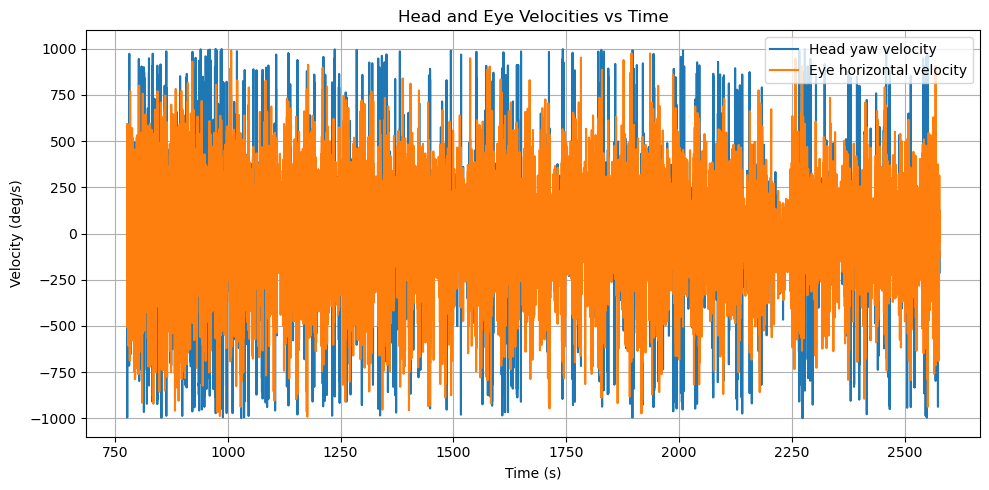

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1️⃣ Extract data ---
eye_time = data['eye_time'].squeeze()
eye_pos = data['eye_deg'][:, 0]  # horizontal eye position (deg)
eye_is_free = data['eye_isSac_free'].squeeze().astype(bool)  # logical mask

opti_time = data['opti_time'].squeeze()
head_yaw = data['opti_headrot_smo'][:, 0]  # yaw (deg)

# --- 2️⃣ Compute velocities (deg/s) ---
eye_hor_vel_full = np.gradient(eye_pos, eye_time)
head_yaw_vel = np.gradient(head_yaw, opti_time)

# --- 3️⃣ Interpolate head velocity to eye timestamps ---
interp_head_yaw_vel = interp1d(
    opti_time, head_yaw_vel,
    bounds_error=False, fill_value="extrapolate"
)
head_yaw_vel_resampled_full = interp_head_yaw_vel(eye_time)

# --- 4️⃣ Get time window from data['t'] 4th column ---
t_start, t_end = data['t'][3, 0], data['t'][3, 1] 
print(f"Using time window: {t_start:.3f} – {t_end:.3f} s")

# Create a mask for the time window
time_mask = (eye_time >= t_start) & (eye_time <= t_end)

free_mask = (
    np.isfinite(eye_hor_vel_full)
    & np.isfinite(head_yaw_vel_resampled_full)
    & (np.abs(head_yaw_vel_resampled_full) <= 1000)
    & (np.abs(eye_hor_vel_full) <= 1000)
    & time_mask
)

# Apply mask
eye_time_sel = eye_time[free_mask]
eye_hor_vel_sel = eye_hor_vel_full[free_mask]
head_yaw_vel_sel = head_yaw_vel_resampled_full[free_mask]

print(f"Samples in window: {np.sum(free_mask)}")

# --- 6️⃣ Plot time series ---
plt.figure(figsize=(10, 5))
plt.plot(eye_time_sel, head_yaw_vel_sel, label='Head yaw velocity', color='tab:blue')
plt.plot(eye_time_sel, eye_hor_vel_sel, label='Eye horizontal velocity', color='tab:orange')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (deg/s)')
plt.title('Head and Eye Velocities vs Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




Random seed used: 1763058353
Random 10-s window: 779.350 – 789.350 s
Correlation results:
Fixation: r = -0.646
Gaze shift: r = -0.066


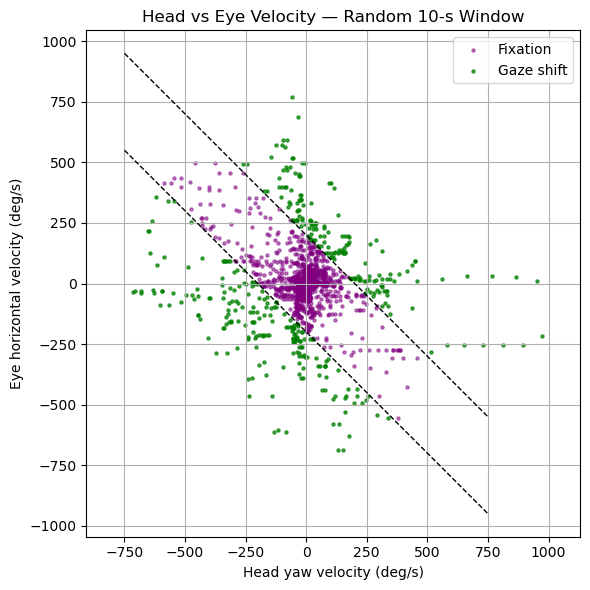

In [6]:
import random
from scipy.stats import pearsonr

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import time

# --- Generate and log a seed ---

seed = 1763058353
print(f"Random seed used: {seed}")

rng = np.random.default_rng(seed)  # independent, local RNG

# --- 🟣 Randomly select a 10-second window within selected time range ---
window_duration = 10.0
valid_start = t_start
valid_end = t_end - window_duration

rand_start = rng.uniform(valid_start, valid_end)  # use rng, not random.uniform
rand_end   = rand_start + window_duration

print(f"Random 10-s window: {rand_start:.3f} – {rand_end:.3f} s")

# Create mask for that 10-s interval
rand_mask = (eye_time_sel >= rand_start) & (eye_time_sel <= rand_end)
# --- 🔶 Detect gaze shifts & fixations within random 10-s window ---
gaze_vel_rand = head_yaw_vel_sel[rand_mask] + eye_hor_vel_sel[rand_mask]
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)



# --- 🧮 Extract velocity pairs for each condition ---
head_fix = head_yaw_vel_sel[rand_mask][is_fix]
eye_fix = eye_hor_vel_sel[rand_mask][is_fix]
head_shift = head_yaw_vel_sel[rand_mask][is_shift]
eye_shift = eye_hor_vel_sel[rand_mask][is_shift]

# --- 📈 Calculate Pearson correlation (r) and p-value ---
r_fix, p_fix = pearsonr(head_fix, eye_fix)
r_shift, p_shift = pearsonr(head_shift, eye_shift)

# --- 🧾 Print results ---
print("Correlation results:")
print(f"Fixation: r = {r_fix:.3f}")
print(f"Gaze shift: r = {r_shift:.3f}")


# --- 🔷 Scatter plot: head vs eye velocity, colored by type ---
plt.figure(figsize=(6, 6))
plt.scatter(
    head_yaw_vel_sel[rand_mask][is_fix],
    eye_hor_vel_sel[rand_mask][is_fix],
    s=5, color='purple', alpha=0.5, label='Fixation'
)
plt.scatter(
    head_yaw_vel_sel[rand_mask][is_shift],
    eye_hor_vel_sel[rand_mask][is_shift],
    s=5, color='green', alpha=0.7, label='Gaze shift'
)

# Reference lines (±1 slope)
x = np.linspace(-750, 750, 200)
plt.plot(x, -200-x, 'k--', linewidth=1)
plt.plot(x, 200-x, 'k--', linewidth=1)

plt.xlabel('Head yaw velocity (deg/s)')
plt.ylabel('Eye horizontal velocity (deg/s)')
plt.title('Head vs Eye Velocity — Random 10-s Window')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


### Key analysis

(1)detect two types of event: 

headv over 200

eyev over 200 but not inclued in the headv

(2)calculate relevant event parameters: peak_velocity, duration

(3)simulated data use Vfix : stable process

Vpulse: each pulse represent a vent

Vrandom: add some noise and smaller pusle than the envet

(4) visualize

(5)t-test of relevant parameter of event generated and real.

(6) use simulated data get figue 6C and calculate the pearson r



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==============================================================
# 🟣 FIXATION STATS
# ==============================================================
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)
head_fix = head_yaw_vel_sel[rand_mask][is_fix]
eye_fix = eye_hor_vel_sel[rand_mask][is_fix]

mean_head_fix = np.mean(head_fix)
std_head_fix = np.std(head_fix)
var_head_fix = np.var(head_fix)

mean_eye_fix = np.mean(eye_fix)
std_eye_fix = np.std(eye_fix)
var_eye_fix = np.var(eye_fix)

# Absolute values
abs_mean_head_fix = np.mean(np.abs(head_fix))
abs_std_head_fix = np.std(np.abs(head_fix))
abs_var_head_fix = np.var(np.abs(head_fix))

abs_mean_eye_fix = np.mean(np.abs(eye_fix))
abs_std_eye_fix = np.std(np.abs(eye_fix))
abs_var_eye_fix = np.var(np.abs(eye_fix))

# Regression
slope_fix, intercept_fix, r_fix, p_fix, stderr_fix = linregress(head_fix, eye_fix)

print("=== FIXATION ===")
print(f"Head mean={mean_head_fix:.2f}, std={std_head_fix:.2f}, var={var_head_fix:.2f}")
print(f"Eye  mean={mean_eye_fix:.2f}, std={std_eye_fix:.2f}, var={var_eye_fix:.2f}")
print(f"|Head| mean={abs_mean_head_fix:.2f}, std={abs_std_head_fix:.2f}, var={abs_var_head_fix:.2f}")
print(f"|Eye|  mean={abs_mean_eye_fix:.2f}, std={abs_std_eye_fix:.2f}, var={abs_var_eye_fix:.2f}")
print(f"Regression slope (eye~head): {slope_fix:.3f}, r={r_fix:.3f}, p={p_fix:.3e}")

# ==============================================================
# 🟣 GAZE SHIFT STATS (same logic as fixation)
# ==============================================================

# Define gaze shift using summed velocity
gaze_sum = head_yaw_vel_sel[rand_mask] + eye_hor_vel_sel[rand_mask]
is_shift2 = np.abs(gaze_sum) > 200    # new definition
shift_head = head_yaw_vel_sel[rand_mask][is_shift2]
shift_eye  = eye_hor_vel_sel[rand_mask][is_shift2]

# ---- Mean / Std / Var ----
mean_head_shift = np.mean(shift_head)
std_head_shift  = np.std(shift_head)
var_head_shift  = np.var(shift_head)

mean_eye_shift = np.mean(shift_eye)
std_eye_shift  = np.std(shift_eye)
var_eye_shift  = np.var(shift_eye)

# ---- Absolute values ----
abs_mean_head_shift = np.mean(np.abs(shift_head))
abs_std_head_shift  = np.std(np.abs(shift_head))
abs_var_head_shift  = np.var(np.abs(shift_head))

abs_mean_eye_shift = np.mean(np.abs(shift_eye))
abs_std_eye_shift  = np.std(np.abs(shift_eye))
abs_var_eye_shift  = np.var(np.abs(shift_eye))

# ---- Regression eye ~ head ----
slope_shift, intercept_shift, r_shift, p_shift, stderr_shift = linregress(shift_head, shift_eye)

print("=== GAZE SHIFT (Vhead + Veye > 200) ===")
print(f"Head mean={mean_head_shift:.2f}, std={std_head_shift:.2f}, var={var_head_shift:.2f}")
print(f"Eye  mean={mean_eye_shift:.2f}, std={std_eye_shift:.2f}, var={var_eye_shift:.2f}")
print(f"|Head| mean={abs_mean_head_shift:.2f}, std={abs_std_head_shift:.2f}, var={abs_var_head_shift:.2f}")
print(f"|Eye|  mean={abs_mean_eye_shift:.2f}, std={abs_std_eye_shift:.2f}, var={abs_var_eye_shift:.2f}")
print(f"Regression slope (eye~head): {slope_shift:.3f}, r={r_shift:.3f}, p={p_shift:.3e}")




=== FIXATION ===
Head mean=-10.42, std=96.72, var=9354.68
Eye  mean=4.11, std=93.39, var=8721.08
|Head| mean=51.08, std=82.79, var=6853.69
|Eye|  mean=54.52, std=75.93, var=5765.11
Regression slope (eye~head): -0.624, r=-0.646, p=1.287e-189
=== GAZE SHIFT (Vhead + Veye > 200) ===
Head mean=-32.88, std=275.44, var=75869.79
Eye  mean=-17.47, std=266.89, var=71232.37
|Head| mean=205.04, std=186.84, var=34911.01
|Eye|  mean=215.03, std=159.05, var=25297.97
Regression slope (eye~head): -0.064, r=-0.066, p=1.901e-01


Sampling rate ≈ 200.0 Hz


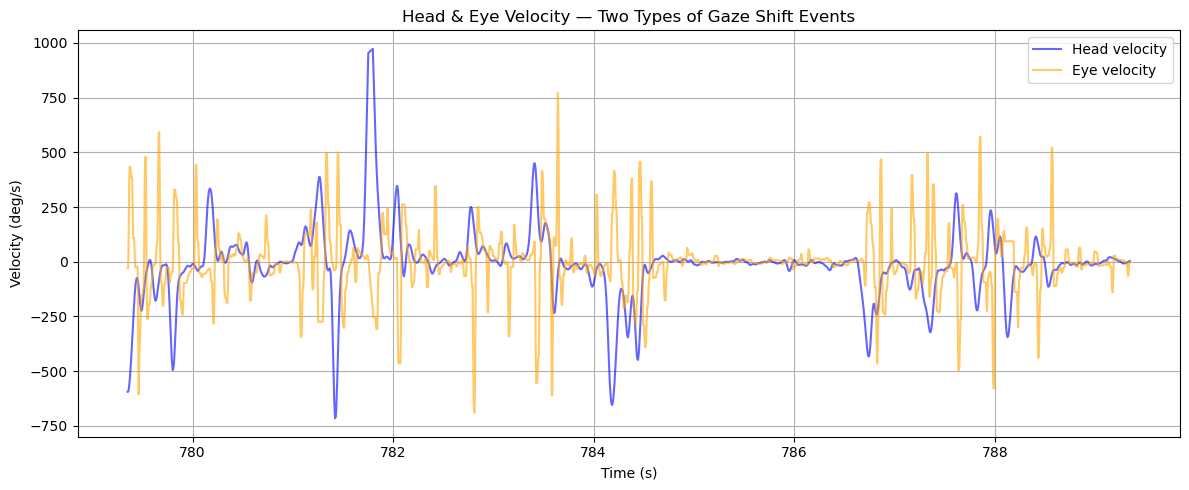

In [8]:
# ==============================================================
# 🔹 Basic variables
# ==============================================================
time = eye_time_sel[rand_mask]
Vhead = head_yaw_vel_sel[rand_mask]
Veye  = eye_hor_vel_sel[rand_mask]

n = len(time)
fs_est = 1 / np.median(np.diff(time))  # approximate sampling rate
print(f"Sampling rate ≈ {fs_est:.1f} Hz")



# ==============================================================
# 🔹 Plot results
# ==============================================================

plt.figure(figsize=(12, 5))
plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)


plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Head & Eye Velocity — Two Types of Gaze Shift Events")
plt.legend(loc='upper right', frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()



Detected Event1 segments (extended):
(0, 18)
(24, 35)
(82, 103)
(156, 176)
(371, 395)
(406, 428)
(470, 500)
(522, 540)
(672, 686)
(794, 817)
(839, 851)
(946, 977)
(982, 1001)
(1000, 1022)
(1458, 1485)
(1480, 1495)
(1581, 1605)
(1639, 1655)
(1682, 1694)
(1709, 1722)
(1740, 1759)


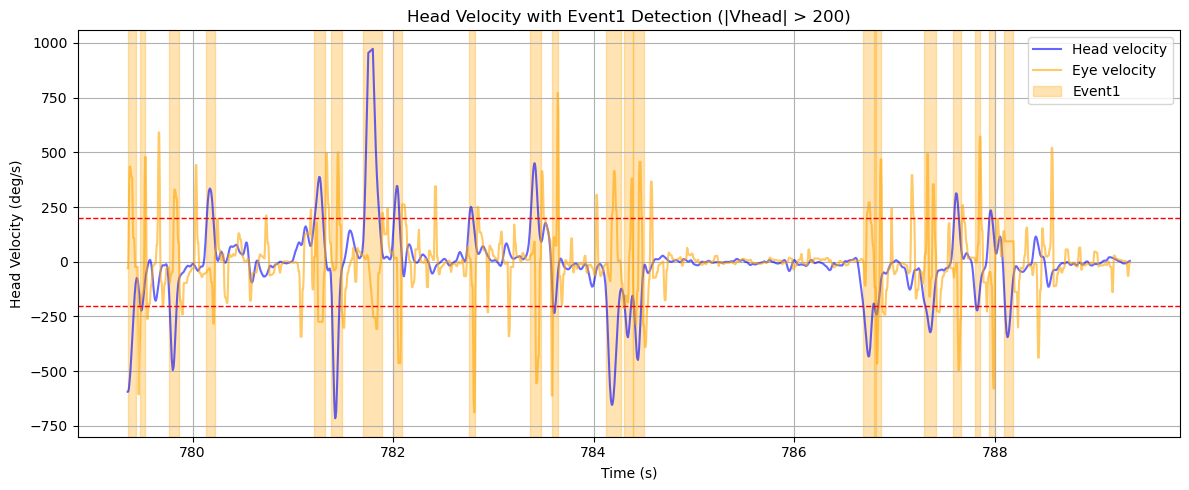

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 🟣 1. Detect Event1 (|Vhead| > 200) with 1-point extension
# --------------------------------------------------------------
time = eye_time_sel[rand_mask]
thr = 200
mask = (Vhead > thr) | (Vhead < -thr)   # boolean mask

event1 = []
start = None

for i, val in enumerate(mask):
    if val:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            # Add 1 sample padding on both sides
            s_ext = max(start - 2, 0)
            e_ext = min(end + 5, len(mask))
            event1.append((s_ext, e_ext))
            start = None

# Catch event that goes to the end
if start is not None:
    s_ext = max(start - 1, 0)
    e_ext = len(mask)
    event1.append((s_ext, e_ext))

print("Detected Event1 segments (extended):")
for ev in event1:
    print(ev)

# --------------------------------------------------------------
# 🟣 2. Plot original figure + threshold + event intervals
# --------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)

# ±200 threshold lines
plt.axhline(thr, color='red', linestyle='--', linewidth=1)
plt.axhline(-thr, color='red', linestyle='--', linewidth=1)

# Highlight Event1 segments
for (s, e) in event1:
    plt.axvspan(time[s], time[e-1], color='orange', alpha=0.3, label="Event1" if 'Event1' not in plt.gca().get_legend_handles_labels()[1] else None)

plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Event2 (|Vhead| > 150 but not Event1) ===
(20, 24)
(35, 39)
(38, 43)
(60, 66)
(69, 73)
(107, 112)
(134, 140)
(275, 279)
(343, 350)
(364, 368)
(395, 403)
(428, 435)
(500, 504)
(509, 513)
(540, 548)
(604, 609)
(689, 694)
(709, 713)
(751, 756)
(817, 823)
(836, 839)
(851, 854)
(926, 931)
(980, 982)
(1022, 1031)
(1034, 1040)
(1495, 1498)
(1497, 1505)
(1515, 1518)
(1554, 1561)
(1605, 1614)
(1656, 1661)
(1694, 1696)
(1705, 1708)
(1766, 1770)
(1806, 1813)
(1833, 1839)


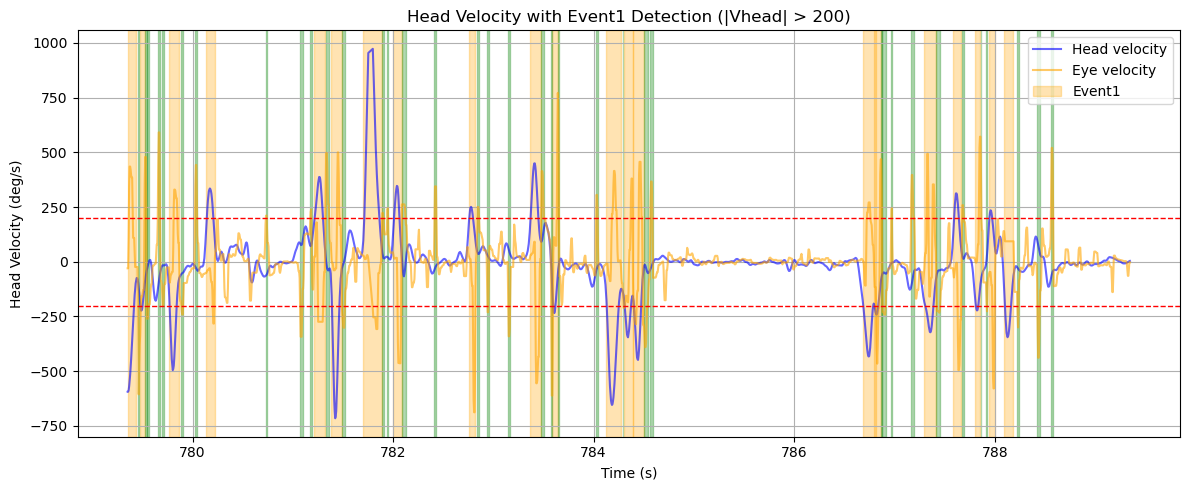

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Build mask for extended Event1
thr1 = 100
mask1 = (Vhead > thr1) | (Vhead < -thr1)
event1_mask = np.zeros_like(mask1, dtype=bool)
for s, e in event1:
    event1_mask[s:e] = True


# ==============================================================
# 🟢 2. Event2 detection: NOT in Event1 & |Vhead| > 100
# ==============================================================

thr2 = 200
mask2_base = (np.abs(Veye) > thr2) & (~event1_mask)

event2 = []
start = None

for i, val in enumerate(mask2_base):
    if val:
        if start is None:
            start = i
    else:
        if start is not None:
            end = i
            # extend by 1 sample
            s_ext = max(start - 1, 0)
            e_ext = min(end + 1, len(mask2_base))

            # ensure no overlap with Event1 after extension
            while s_ext < e_ext and event1_mask[s_ext]:
                s_ext += 1
            while e_ext > s_ext and event1_mask[e_ext - 1]:
                e_ext -= 1

            if s_ext < e_ext:
                event2.append((s_ext, e_ext))

            start = None

# catch event at tail
if start is not None:
    s_ext = max(start - 1, 0)
    e_ext = len(mask2_base)

    while s_ext < e_ext and event1_mask[s_ext]:
        s_ext += 1
    while e_ext > s_ext and event1_mask[e_ext - 1]:
        e_ext -= 1

    if s_ext < e_ext:
        event2.append((s_ext, e_ext))

print("=== Event2 (|Vhead| > 150 but not Event1) ===")
for ev in event2:
    print(ev)




# 🔷 3. Plot Event1 and Event2 on original trace
# ==============================================================

plt.figure(figsize=(12, 5))

plt.plot(time, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye,  label='Eye velocity',  color='orange', alpha=0.6)

# ±200 threshold lines
plt.axhline(thr2, color='red', linestyle='--', linewidth=1)
plt.axhline(-thr2, color='red', linestyle='--', linewidth=1)

# Highlight Event1 segments
for (s, e) in event1:
    plt.axvspan(time[s], time[e-1], color='orange', alpha=0.3, label="Event1" if 'Event1' not in plt.gca().get_legend_handles_labels()[1] else None)

for (s, e) in event2:
    plt.axvspan(time[s], time[e-1], color='green', alpha=0.3, label="Event1" if 'Event1' not in plt.gca().get_legend_handles_labels()[1] else None)


plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [11]:
fs = 200  # Hz

def compute_head_eye_event_stats(events, Vhead, Veye, fs):
    """
    For each event (s, e), compute:
      - peak |Vhead|
      - peak |Veye|
      - duration (sec)
    Then return mean/std for each, plus n_events.
    """
    if not events:
        return {
            "head_peak_mean": np.nan,
            "head_peak_std":  np.nan,
            "eye_peak_mean":  np.nan,
            "eye_peak_std":   np.nan,
            "dur_mean":       np.nan,
            "dur_std":        np.nan,
            "n_events":       0,
        }

    head_peaks = []
    eye_peaks  = []
    durations  = []

    for (s, e) in events:
        seg_head = Vhead[s:e]
        seg_eye  = Veye[s:e]
        if len(seg_head) == 0 or len(seg_eye) == 0:
            continue

        # absolute peak amplitudes
        head_peaks.append(np.max(np.abs(seg_head)))
        eye_peaks.append(np.max(np.abs(seg_eye)))

        # duration in seconds
        durations.append((e - s) / fs)

    if len(head_peaks) == 0:
        return {
            "head_peak_mean": np.nan,
            "head_peak_std":  np.nan,
            "eye_peak_mean":  np.nan,
            "eye_peak_std":   np.nan,
            "dur_mean":       np.nan,
            "dur_std":        np.nan,
            "n_events":       0,
        }

    head_peaks = np.array(head_peaks)
    eye_peaks  = np.array(eye_peaks)
    durations  = np.array(durations)

    return {
        "head_peak_mean": float(np.mean(head_peaks)),
        "head_peak_std":  float(np.std(head_peaks)),
        "eye_peak_mean":  float(np.mean(eye_peaks)),
        "eye_peak_std":   float(np.std(eye_peaks)),
        "dur_mean":       float(np.mean(durations)),
        "dur_std":        float(np.std(durations)),
        "n_events":       int(len(durations)),
    }

# ----------------------------------------------------------
# 🟣 Stats for Event1 and Event2
# ----------------------------------------------------------
stats_type1 = compute_head_eye_event_stats(event1, Vhead, Veye, fs)
stats_type2 = compute_head_eye_event_stats(event2, Vhead, Veye, fs)

print("=== stats_type1 (Event1) ===")
for k, v in stats_type1.items():
    print(f"{k}: {v}")

print("\n=== stats_type2 (Event2) ===")
for k, v in stats_type2.items():
    print(f"{k}: {v}")


=== stats_type1 (Event1) ===
head_peak_mean: 407.6822951369742
head_peak_std: 187.08107240202258
eye_peak_mean: 440.6720312071342
eye_peak_std: 144.81768943210201
dur_mean: 0.09785714285714286
dur_std: 0.028054853946010355
n_events: 21

=== stats_type2 (Event2) ===
head_peak_mean: 65.19060389414695
head_peak_std: 36.73568678847646
eye_peak_mean: 351.85593452566076
eye_peak_std: 130.81624165003385
dur_mean: 0.025675675675675677
dur_std: 0.009238737640614707
n_events: 37


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import time

# --- Generate and log a seed ---
print(f"Random seed used: {seed}")
np.random.seed(seed)


# --- 1. Time vector ---
fs = 200          # Hz
dt = 1/fs
T = 10.0
time = np.arange(0, T, dt)
n_samples = len(time)

# --- 2. Fixation baseline ---
A_head_fix = 10
A_eye_fix  = 10
r = slope_fix
f_fix = 0.5  # Hz


# Noise std = sqrt(var_data - var_sin)
noise_std_head_fix = 5
noise_std_eye_fix  = 5

# Generate fixation baseline
Vhead_fix = A_head_fix * np.sin(2*np.pi*f_fix*time) 
Veye_fix  = r * Vhead_fix

# ==============================================================
# 🔹 Create event1 and event2 from stats_type1 and stats_type2
#    (SWAPPED: generation event1 uses stats_type2, event2 uses stats_type1)
# ==============================================================



fs_est = fs  # use actual sampling rate

# --- Targets (how many events we want to simulate) ---

if stats_type1 is not None:
    n_events1_target = int(stats_type1.get('n_events', 0))   # event1 ← stats_type2
    mean_dur1 = float(stats_type1.get('dur_mean', 0.0))      # seconds
    std_dur1  = float(stats_type1.get('dur_std',  0.0))      # seconds
else:
    n_events1_target = 0
    mean_dur1 = 0.0
    std_dur1  = 0.0

if stats_type2 is not None:
    n_events2_target = int(stats_type2.get('n_events', 0))   # event2 ← stats_type1
    mean_dur2 = float(stats_type2.get('dur_mean', 0.0))
    std_dur2  = float(stats_type2.get('dur_std',  0.0))
else:
    n_events2_target = 0
    mean_dur2 = 0.0
    std_dur2  = 0.0

occupied = np.zeros(n_samples, dtype=bool)
final_event1 = []
final_event2 = []

# --------------------------------------------------------------
# 🟣 Generate non-overlapping Event1 (from stats_type2)
# --------------------------------------------------------------
max_attempts1 = 1000 * max(1, n_events1_target)
attempts = 0

while len(final_event1) < n_events1_target and attempts < max_attempts1:
    attempts += 1

    # random duration from N(mean, std), at least 2 samples
    dur_sec = max(np.random.normal(mean_dur1, std_dur1), 2/fs_est)
    duration_samples = max(int(round(dur_sec * fs_est)), 2)
    if duration_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - duration_samples)
    end_idx = start_idx + duration_samples

    # ensure no overlap
    if np.any(occupied[start_idx:end_idx]):
        continue

    final_event1.append((start_idx, end_idx))
    occupied[start_idx:end_idx] = True

if len(final_event1) < n_events1_target:
    print(f"Warning: requested {n_events1_target} Event1, placed {len(final_event1)}.")


# --------------------------------------------------------------
# 🟢 Generate non-overlapping Event2 (from stats_type1)
#     (cannot overlap Event1 or other Event2)
# --------------------------------------------------------------
max_attempts2 = 1000 * max(1, n_events2_target)
attempts = 0

while len(final_event2) < n_events2_target and attempts < max_attempts2:
    attempts += 1

    dur_sec = max(np.random.normal(mean_dur2, std_dur2), 2/fs_est)
    duration_samples = max(int(round(dur_sec * fs_est)), 2)
    if duration_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - duration_samples)
    end_idx = start_idx + duration_samples

    # still using same occupied mask so they don't overlap
    if np.any(occupied[start_idx:end_idx]):
        continue

    final_event2.append((start_idx, end_idx))
    occupied[start_idx:end_idx] = True

if len(final_event2) < n_events2_target:
    print(f"Warning: requested {n_events2_target} Event2, placed {len(final_event2)}.")

print("Final Event1 segments (from stats_type2):", final_event1)
print("Final Event2 segments (from stats_type1):", final_event2)
print("Counts: detected type2 =", 
      stats_type2.get('n_events', 0) if stats_type2 is not None else 0,
      ", simulated Event1 =", len(final_event1))
print("        detected type1 =", 
      stats_type1.get('n_events', 0) if stats_type1 is not None else 0,
      ", simulated Event2 =", len(final_event2))


# ==============================================================
# 🔹 Generate Vhead_event and Veye_event from these events
# ==============================================================

Vhead_event = np.zeros_like(time)
Veye_event  = np.zeros_like(time)

# --------------------------------------------------------------
# --- New Event2: eye-only sin pulses (uses stats_type1) ---
#     (since we swapped: event2 ↔ type1 stats)
# --------------------------------------------------------------
if stats_type1 is not None:
    eye_peak_mean1 = float(stats_type2.get('eye_peak_mean', 0.0))
    eye_peak_std1  = float(stats_type2.get('eye_peak_std',  0.0))
else:
    eye_peak_mean1 = 0.0
    eye_peak_std1  = 0.0

for s, e in final_event2:
    N = e - s
    if N <= 1:
        continue
    D = N * dt
    t_local = np.arange(N) * dt

    # amplitude: random from peak mean/std (magnitude)
    A_eye = np.random.normal(eye_peak_mean1, eye_peak_std1)
    A_eye = np.abs(A_eye)

    # full sine pulse from 0 to pi
    pulse_eye = A_eye * np.sin(np.pi * t_local / D)

    # random direction sign
    sign_evt = np.random.choice([-1, 1])

    Veye_event[s:e] += sign_evt * pulse_eye
    # eye-only: no head event added here (head stays at baseline)


# --------------------------------------------------------------
# --- New Event1: combined head+eye with VOR (uses stats_type2) ---
#     (since we swapped: event1 ↔ type2 stats)
# --------------------------------------------------------------
if stats_type2 is not None:
    head_peak_mean2 = float(stats_type1.get('head_peak_mean', 0.0))
    head_peak_std2  = float(stats_type1.get('head_peak_std',  0.0))
    eye_peak_mean2  = float(stats_type1.get('eye_peak_mean',  0.0))
    eye_peak_std2   = float(stats_type1.get('eye_peak_std',   0.0))
else:
    head_peak_mean2 = 0.0
    head_peak_std2  = 0.0
    eye_peak_mean2  = 0.0
    eye_peak_std2   = 0.0

for s, e in final_event1:
    N = e - s
    if N <= 1:
        continue

    D_event = N * dt
    t = np.arange(N) * dt  # local time

    # random amplitudes from peak mean/std (magnitudes)
    A_head = np.abs(np.random.normal(head_peak_mean2, head_peak_std2))
    A_eye  = np.abs(np.random.normal(eye_peak_mean2,  eye_peak_std2))
    A_eye_VOR  = np.abs(np.random.normal(eye_peak_mean2,  eye_peak_std2))
    # timing: eye earlier, head longer & delayed
    D_eye  = 0.60 * D_event
    D_head = 1.10 * D_event
    delay_head = 0.10 * D_event
    D_eye_VOR = 0.40 * D_event

    t_eye  = t
    t_head = t - delay_head

    eye_win  = (t_eye  >= 0) & (t_eye  <= D_eye)
    head_win = (t_head >= 0) & (t_head <= D_head)

    eye_core  = np.zeros_like(t)
    head_core = np.zeros_like(t)
    eye_VOR = np.zeros_like(t)
    
    eye_core[eye_win]   = A_eye  * np.sin(np.pi * t_eye[eye_win]  / D_eye)
    head_core[head_win] = A_head * np.sin(np.pi * t_head[head_win] / D_head)

    # VOR re-engagement: subtract fraction of head after its peak
    t_head_peak = delay_head + 0.5 * D_head
    t_head_end = delay_head +  D_head
    vor_mask = (t >= t_head_peak) & (t <= t_head_end)
    eye_VOR[vor_mask] = A_eye_VOR * np.sin(np.pi * t_eye[vor_mask] / D_head)

    pulse_head = head_core
    pulse_eye  = eye_core 
    VOR_eye = eye_VOR
    # random global direction sign
    sign_evt = np.random.choice([-1, 1])

    Vhead_event[s:e] += sign_evt * pulse_head
    Veye_event[s:e]  += sign_evt * pulse_eye
    Veye_event[s:e]  -= sign_evt * VOR_eye


# ==============================================================
# 🔹 Random head/eye pulses (no overlap with events)
# ==============================================================

n_rand_head = 50
n_rand_eye  = 10

head_dur_mean = 0.08   # s
head_dur_std  = 0.02   # s
eye_dur_mean  = 0.02   # s
eye_dur_std   = 0.005  # s

pulse_mean = 30.0      # deg/s
pulse_std  = 20.0      # deg/s

# 👉 VOR gain (set this to whatever you want)
# e.g. r = slope_fix somewhere above; here I use r_VOR to be explicit
r_VOR = r   # or r_VOR = 0.8, etc.

# Start from event-occupied mask so pulses avoid events
occupied_pulse = occupied.copy()

head_pulses = []
eye_pulses  = []

# --- Head pulses ---
max_attempts_head = 1000 * max(1, n_rand_head)
attempts = 0

while len(head_pulses) < n_rand_head and attempts < max_attempts_head:
    attempts += 1

    dur_sec = max(np.random.normal(head_dur_mean, head_dur_std), 2/fs)
    dur_samples = max(int(round(dur_sec * fs)), 2)
    if dur_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - dur_samples)
    end_idx = start_idx + dur_samples

    # avoid overlap with events & other pulses
    if np.any(occupied_pulse[start_idx:end_idx]):
        continue

    head_pulses.append((start_idx, end_idx))
    occupied_pulse[start_idx:end_idx] = True

if len(head_pulses) < n_rand_head:
    print(f"Warning: requested {n_rand_head} head pulses, placed {len(head_pulses)}.")

# --- Eye pulses (independent eye-only pulses, still allowed) ---
max_attempts_eye = 1000 * max(1, n_rand_eye)
attempts = 0

while len(eye_pulses) < n_rand_eye and attempts < max_attempts_eye:
    attempts += 1

    dur_sec = max(np.random.normal(eye_dur_mean, eye_dur_std), 2/fs)
    dur_samples = max(int(round(dur_sec * fs)), 2)
    if dur_samples >= n_samples:
        continue

    start_idx = np.random.randint(0, n_samples - dur_samples)
    end_idx = start_idx + dur_samples

    # avoid overlap with events & head pulses & other eye pulses
    if np.any(occupied_pulse[start_idx:end_idx]):
        continue

    eye_pulses.append((start_idx, end_idx))
    occupied_pulse[start_idx:end_idx] = True

if len(eye_pulses) < n_rand_eye:
    print(f"Warning: requested {n_rand_eye} eye pulses, placed {len(eye_pulses)}.")

print("Random head pulses:", head_pulses)
print("Random eye pulses:", eye_pulses)

# ==============================================================
# 🔹 Add random pulses to Vhead_event and Veye_event
# ==============================================================

Vhead_random = np.zeros_like(time)
Veye_random  = np.zeros_like(time)

# --- Head pulses WITH VOR on the eye: Veye = r * Vhead ---
for s, e in head_pulses:
    N = e - s
    if N <= 1:
        continue
    D = N * dt
    t_local = np.arange(N) * dt

    A = np.abs(np.random.normal(pulse_mean, pulse_std))
    pulse = A * np.sin(np.pi * t_local / D)  # half-sine

    sign_evt = np.random.choice([-1, 1])

    # Head pulse
    Vhead_random[s:e] += sign_evt * pulse
    # VOR eye pulse, locked to the head (same shape, scaled by r_VOR)
    Veye_random[s:e]  += r_VOR * sign_evt * pulse

# --- Extra eye-only pulses (if you still want random eye stuff) ---
for s, e in eye_pulses:
    N = e - s
    if N <= 1:
        continue
    D = N * dt
    t_local = np.arange(N) * dt

    A = np.abs(np.random.normal(pulse_mean, pulse_std))
    pulse = A * np.sin(np.pi * t_local / D)

    sign_evt = np.random.choice([-1, 1])
    Veye_random[s:e] += sign_evt * pulse

# --- Final simulated signals ---
Vhead_sim = Vhead_fix + Vhead_event + Vhead_random
Veye_sim  = Veye_fix  + Veye_event  + Veye_random

Random seed used: 1763058353
Final Event1 segments (from stats_type2): [(1516, 1529), (820, 852), (263, 290), (1407, 1433), (55, 64), (1201, 1214), (1435, 1456), (1697, 1715), (774, 806), (229, 255), (1844, 1862), (1576, 1602), (106, 124), (1319, 1346), (994, 1015), (1227, 1239), (739, 758), (1103, 1125), (1026, 1048), (1674, 1691), (192, 220)]
Final Event2 segments (from stats_type1): [(1792, 1796), (1985, 1991), (139, 141), (1785, 1791), (1161, 1167), (1880, 1882), (1488, 1492), (1748, 1754), (1135, 1137), (436, 438), (356, 361), (863, 865), (1827, 1832), (1466, 1474), (569, 575), (1972, 1975), (1736, 1742), (509, 517), (1385, 1390), (370, 376), (221, 226), (311, 315), (1129, 1135), (1727, 1732), (1277, 1283), (1146, 1153), (854, 858), (1078, 1082), (1890, 1893), (1612, 1618), (588, 593), (148, 153), (581, 588), (517, 524), (1665, 1668), (1300, 1306), (176, 181)]
Counts: detected type2 = 37 , simulated Event1 = 21
        detected type1 = 21 , simulated Event2 = 37
Random head pulses

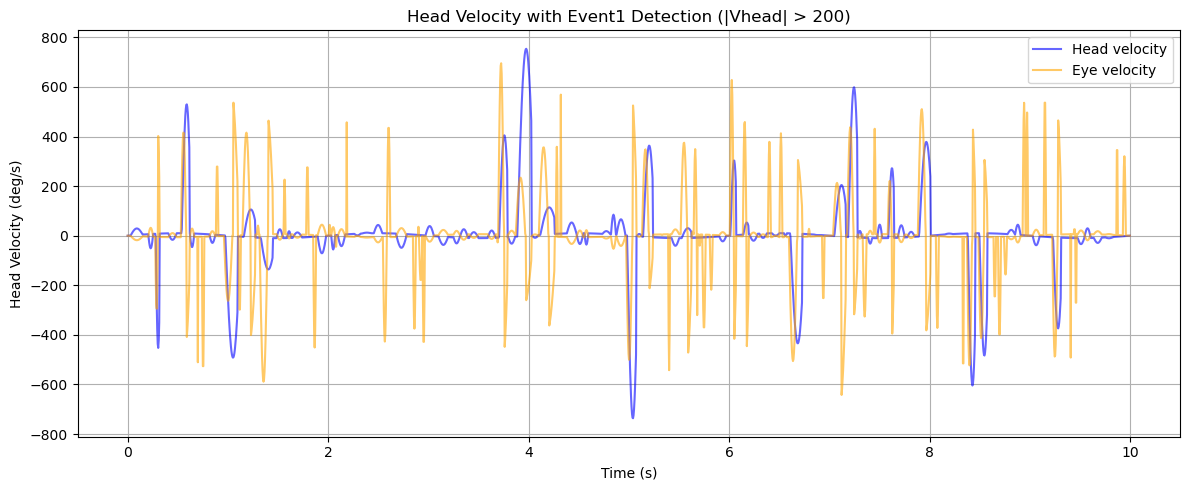

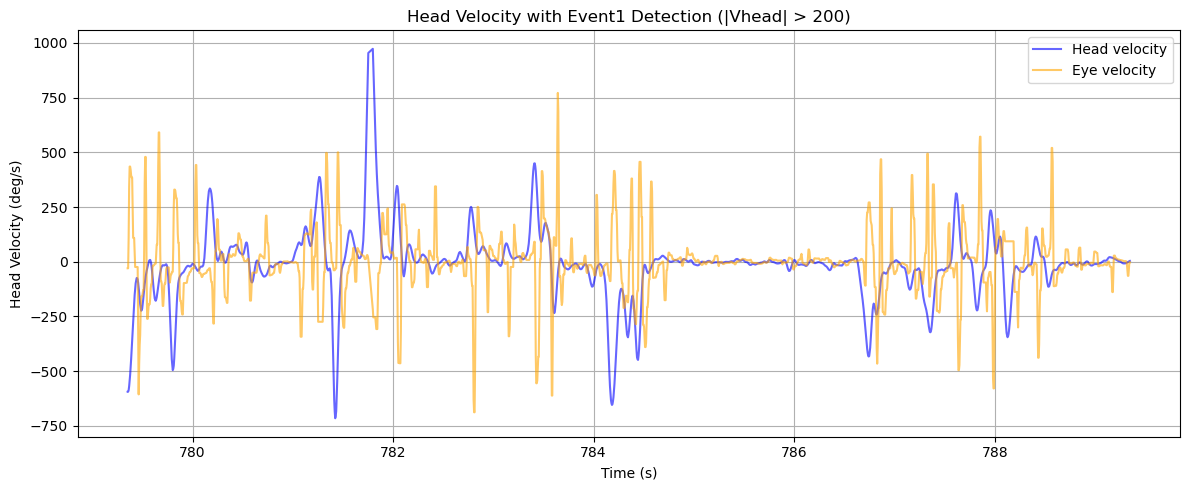

In [13]:
# 🔷 3. Plot Event1 and Event2 on original trace
# ==============================================================

plt.figure(figsize=(12, 5))

plt.plot(time, Vhead_sim, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time, Veye_sim,  label='Eye velocity',  color='orange', alpha=0.6)


plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


time2 = eye_time_sel[rand_mask]

plt.figure(figsize=(12, 5))

plt.plot(time2, Vhead, label='Head velocity', color='blue', alpha=0.6)
plt.plot(time2, Veye,  label='Eye velocity',  color='orange', alpha=0.6)


plt.xlabel("Time (s)")
plt.ylabel("Head Velocity (deg/s)")
plt.title("Head Velocity with Event1 Detection (|Vhead| > 200)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Random Event1 (combined) chosen: (1674, 1691) duration = 0.085 s
Random Event2 (eye-only) chosen: (1078, 1082) duration = 0.02 s


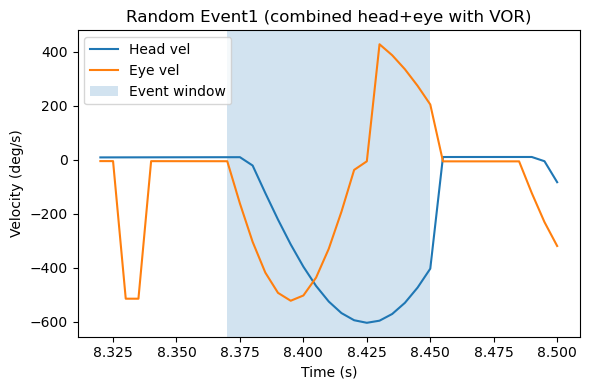

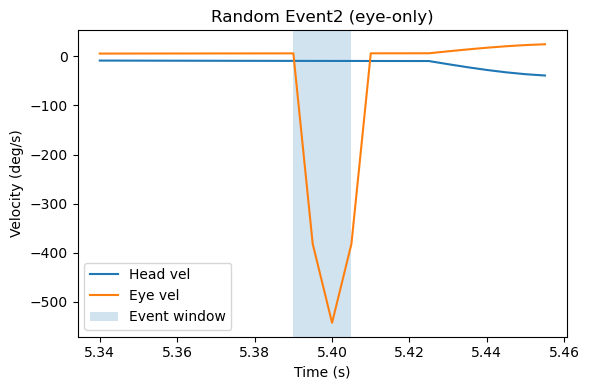

In [14]:
def choose_random_event(events, fs):
    """
    Randomly choose one event from a list of (start, end) index tuples.
    Returns (event_tuple, duration_sec) or (None, None) if list is empty.
    """
    if not events:
        return None, None
    idx = np.random.randint(len(events))
    evt = events[idx]
    dur_sec = (evt[1] - evt[0]) / fs
    return evt, dur_sec

def plot_event_with_padding(time, Vhead, Veye, event, fs, pad_sec=0.05, title=""):
    """
    Plot head & eye velocity around a given (start, end) event with padding.
    """
    if event is None:
        print("No event to plot.")
        return
    
    s, e = event
    pad_samples = int(round(pad_sec * fs))

    start_idx = max(0, s - pad_samples)
    end_idx   = min(len(time), e + pad_samples)

    idx = slice(start_idx, end_idx)

    t_win     = time[idx]
    head_win  = Vhead[idx]
    eye_win   = Veye[idx]

    plt.figure(figsize=(6, 4))
    plt.plot(t_win, head_win, label='Head vel')
    plt.plot(t_win, eye_win, label='Eye vel')

    # Highlight event window
    plt.axvspan(time[s], time[e-1], alpha=0.2, label='Event window')

    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (deg/s)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Randomly choose one event of each type ---
evt1, dur1 = choose_random_event(final_event1, fs)
evt2, dur2 = choose_random_event(final_event2, fs)

print("Random Event1 (combined) chosen:", evt1, "duration =", dur1, "s")
print("Random Event2 (eye-only) chosen:", evt2, "duration =", dur2, "s")

# --- Plot them from the full simulated signal (including baseline & random pulses) ---
plot_event_with_padding(
    time, Vhead_sim, Veye_sim,
    evt1, fs, pad_sec=0.05,
    title="Random Event1 (combined head+eye with VOR)"
)

plot_event_with_padding(
    time, Vhead_sim, Veye_sim,
    evt2, fs, pad_sec=0.05,
    title="Random Event2 (eye-only)"
)


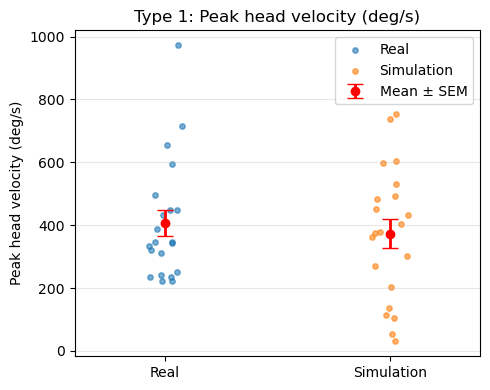

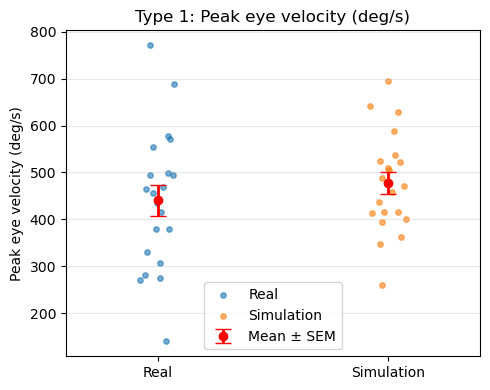

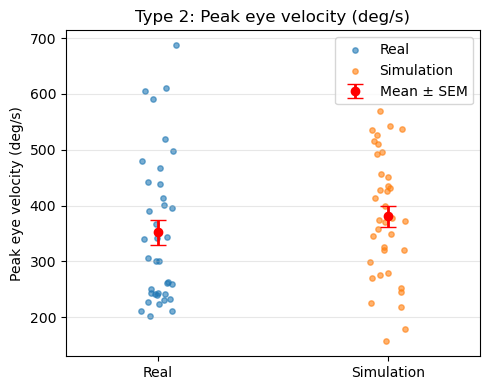

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==============================================================
# 🔹 Helper: extract per-event velocity samples (or means)
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==============================================================
# 🔹 Helper: extract per-event *peak* velocity
# ==============================================================

def collect_event_peaks(V, events):
    """
    For each event (s, e), compute the peak absolute velocity:
        peak_v = max(|V[s:e]|)
    Returns one value per event.
    """
    peaks = []
    for s, e in events or []:
        s = max(0, int(s)); e = min(int(e), len(V))
        if e - s < 1:
            continue
        seg = np.asarray(V[s:e])
        seg = seg[np.isfinite(seg)]
        if seg.size == 0:
            continue
        peaks.append(np.max(np.abs(seg)))
    if not peaks:
        return np.array([])
    return np.asarray(peaks, dtype=float)



# ==============================================================
# 🔹 One-axes comparison: Origin vs Sim for a single velocity
# ==============================================================
def one_axis_peak_compare(V_orig, events_orig,
                          V_sim,  events_sim,
                          vel_label="Peak velocity (deg/s)",
                          title_prefix="Type 1",
                          use_sem=True):
    """
    Compare per-event *peak* velocity between Origin (real) and Simulation.

    - x-axis: two categories ("Real", "Simulation")
    - y-axis: peak |V| per event
    - scatter points for each event
    - mean ± error bar (SEM or SD) for each group
    """
    # Collect per-event peak velocities
    peak_orig = collect_event_peaks(V_orig, events_orig)
    peak_sim  = collect_event_peaks(V_sim,  events_sim)

    # Early exit if no data
    if peak_orig.size == 0 and peak_sim.size == 0:
        print(f"{title_prefix} – {vel_label}: no data to plot.")
        return

    plt.figure(figsize=(5, 4))

    # --- Scatter points with jitter ---
    if peak_orig.size:
        x0 = np.zeros_like(peak_orig, dtype=float) \
             + (-0.08 + 0.16*np.random.rand(peak_orig.size))
        plt.scatter(x0, peak_orig, alpha=0.6, s=15, label="Real")

    if peak_sim.size:
        x1 = np.ones_like(peak_sim, dtype=float) \
             + (-0.08 + 0.16*np.random.rand(peak_sim.size))
        plt.scatter(x1, peak_sim, alpha=0.6, s=15, label="Simulation")

    # --- Mean + error bar (SEM or SD) ---
    vals = []
    labels = []

    if peak_orig.size:
        m_real = peak_orig.mean()
        if use_sem:
            err_real = peak_orig.std(ddof=1) / np.sqrt(len(peak_orig))
        else:
            err_real = peak_orig.std(ddof=1)
        vals.append(m_real)
        labels.append(err_real)
    else:
        vals.append(np.nan)
        labels.append(0.0)

    if peak_sim.size:
        m_sim = peak_sim.mean()
        if use_sem:
            err_sim = peak_sim.std(ddof=1) / np.sqrt(len(peak_sim))
        else:
            err_sim = peak_sim.std(ddof=1)
        vals.append(m_sim)
        labels.append(err_sim)
    else:
        vals.append(np.nan)
        labels.append(0.0)

    # x positions for means: 0 (real), 1 (sim)
    x_mean = [0, 1]
    plt.errorbar(
        x_mean, vals,
        yerr=labels,
        fmt='o', capsize=6, linewidth=2, color='red',
        label="Mean ± " + ("SEM" if use_sem else "SD")
    )

    plt.xticks([0, 1], ["Real", "Simulation"])
    plt.ylabel(vel_label)
    plt.title(f"{title_prefix}: {vel_label}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.xlim(-0.4, 1.4)
    plt.tight_layout()
    plt.legend()
    plt.show()


# ==============================================================
# 🔹 Example usage
# ==============================================================

# You already have:
#   Origin: Vhead, Veye, final_type1, type2_events
#   Sim   : Vhead_real, Veye_real, final_event1, final_event2


# Figure 1: head peak velocity
one_axis_peak_compare(
    V_orig=Vhead,        events_orig=event1,       # real
    V_sim=Vhead_sim,     events_sim=final_event1,  # sim
    vel_label="Peak head velocity (deg/s)",
    title_prefix="Type 1"
)

# Figure 2: eye peak velocity
one_axis_peak_compare(
    V_orig=Veye,         events_orig=event1,
    V_sim=Veye_sim,      events_sim=final_event1,
    vel_label="Peak eye velocity (deg/s)",
    title_prefix="Type 1"
)


# Figure 2: eye peak velocity
one_axis_peak_compare(
    V_orig=Veye,         events_orig=event2,
    V_sim=Veye_sim,      events_sim=final_event2,
    vel_label="Peak eye velocity (deg/s)",
    title_prefix="Type 2"
)



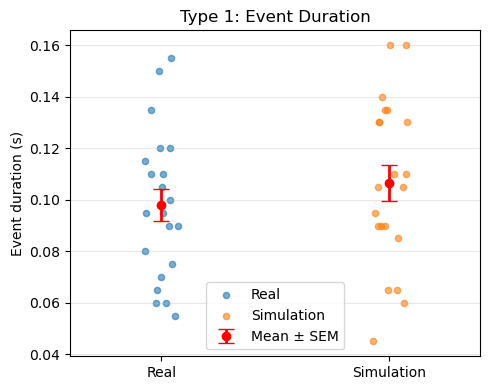

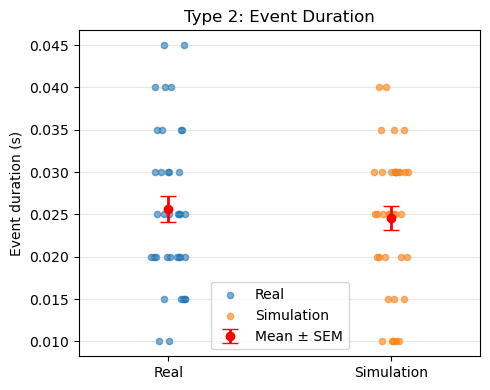

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
# 🔹 Helper: extract per-event *duration* only
# ==============================================================

def collect_event_durations(events, fs):
    """
    For each event (s, e), compute the duration in seconds:
        duration = (e - s) / fs
    Returns one value per event.
    """
    durs = []
    for s, e in events or []:
        s = int(s)
        e = int(e)
        if e - s < 1:
            continue
        durs.append((e - s) / fs)

    if not durs:
        return np.array([])
    return np.asarray(durs, dtype=float)


# ==============================================================
# 🔹 One-axes comparison: Real vs Simulation durations
# ==============================================================

def one_axis_duration_compare(events_real, events_sim,
                              fs,
                              title_prefix="Type 1",
                              use_sem=True):
    """
    Compare per-event durations between Real and Simulation.

    - x-axis: "Real" vs "Simulation"
    - y-axis: event duration (s)
    - scatter points per event
    - mean ± error bar (SEM or SD)
    """
    dur_real = collect_event_durations(events_real, fs)
    dur_sim  = collect_event_durations(events_sim,  fs)

    if dur_real.size == 0 and dur_sim.size == 0:
        print(f"{title_prefix} – Duration: no data to plot.")
        return

    plt.figure(figsize=(5, 4))

    # --- Scatter points with jitter ---
    if dur_real.size:
        x0 = np.zeros_like(dur_real, dtype=float) \
             + (-0.08 + 0.16 * np.random.rand(dur_real.size))
        plt.scatter(x0, dur_real, alpha=0.6, s=20, label="Real")

    if dur_sim.size:
        x1 = np.ones_like(dur_sim, dtype=float) \
             + (-0.08 + 0.16 * np.random.rand(dur_sim.size))
        plt.scatter(x1, dur_sim, alpha=0.6, s=20, label="Simulation")

    # --- Mean + error bars ---
    vals = []
    errs = []

    # Real mean ± SEM/SD
    if dur_real.size:
        m_real = dur_real.mean()
        err_real = dur_real.std(ddof=1) / np.sqrt(len(dur_real)) if use_sem else dur_real.std(ddof=1)
        vals.append(m_real)
        errs.append(err_real)
    else:
        vals.append(np.nan); errs.append(0.0)

    # Simulated mean ± SEM/SD
    if dur_sim.size:
        m_sim = dur_sim.mean()
        err_sim = dur_sim.std(ddof=1) / np.sqrt(len(dur_sim)) if use_sem else dur_sim.std(ddof=1)
        vals.append(m_sim)
        errs.append(err_sim)
    else:
        vals.append(np.nan); errs.append(0.0)

    x_mean = [0, 1]
    plt.errorbar(
        x_mean, vals, yerr=errs,
        fmt='o', capsize=6, linewidth=2, color='red',
        label="Mean ± " + ("SEM" if use_sem else "SD")
    )

    plt.xticks([0, 1], ["Real", "Simulation"])
    plt.ylabel("Event duration (s)")
    plt.title(f"{title_prefix}: Event Duration")
    plt.grid(True, axis="y", alpha=0.3)
    plt.xlim(-0.4, 1.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==============================================================
# 🔹 Example usage
# ==============================================================

# fs = 200  # Hz
# Real events: event1, event2
# Sim events: final_event1, final_event2

# --- Type 1 duration ---
one_axis_duration_compare(
    events_real=event1,
    events_sim=final_event1,
    fs=fs,
    title_prefix="Type 1"
)

# --- Type 2 duration ---
one_axis_duration_compare(
    events_real=event2,
    events_sim=final_event2,
    fs=fs,
    title_prefix="Type 2"
)


In [17]:
import numpy as np
from scipy.stats import ttest_ind

# ==============================================================
# 🔹 Duration extractor (already defined earlier)
# ==============================================================

def collect_event_durations(events, fs):
    durs = []
    for s, e in events or []:
        if e - s < 1:
            continue
        durs.append((e - s) / fs)
    return np.asarray(durs, dtype=float) if durs else np.array([])


# ==============================================================
# 🔹 Peak velocity extractor (already defined)
# ==============================================================

def collect_event_peaks(V, events):
    peaks = []
    for s, e in events or []:
        seg = V[s:e]
        if len(seg) == 0:
            continue
        peaks.append(np.max(np.abs(seg)))
    return np.asarray(peaks, dtype=float) if peaks else np.array([])


# ==============================================================
# 🔹 T-test helper + Cohen's d
# ==============================================================

def cohens_d(x, y):
    """Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    
    pooled_sd = np.sqrt(((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd if pooled_sd > 0 else np.nan


def do_ttest(real_vals, sim_vals, label=""):
    """
    Perform independent-samples t-test on real vs sim values.
    Prints t-stat, p-value, means, and Cohen's d.
    """
    real_vals = np.asarray(real_vals)
    sim_vals  = np.asarray(sim_vals)

    # Remove NaNs
    real_vals = real_vals[np.isfinite(real_vals)]
    sim_vals  = sim_vals[np.isfinite(sim_vals)]

    if len(real_vals) < 2 or len(sim_vals) < 2:
        print(f"{label}: not enough data for t-test")
        return

    t_stat, p_val = ttest_ind(real_vals, sim_vals, equal_var=False)
    d = cohens_d(real_vals, sim_vals)

    print(f"\n========== T-test: {label} ==========")
    print(f"Real (n={len(real_vals)}): mean={real_vals.mean():.3f}, SD={real_vals.std(ddof=1):.3f}")
    print(f"Sim  (n={len(sim_vals)}): mean={sim_vals.mean():.3f}, SD={sim_vals.std(ddof=1):.3f}")
    print(f"t = {t_stat:.4f}, p = {p_val:.6f}")
    print(f"Cohen's d = {d:.4f}")
    print("========================================")


# ==============================================================
# 🔹 Run T-tests for Type 1 and Type 2 (duration + peak velocities)
# ==============================================================

# ----------- Type 1 -----------
dur1_real = collect_event_durations(event1, fs)
dur1_sim  = collect_event_durations(final_event1, fs)

head_peak1_real = collect_event_peaks(Vhead, event1)
head_peak1_sim  = collect_event_peaks(Vhead_sim, final_event1)

eye_peak1_real  = collect_event_peaks(Veye, event1)
eye_peak1_sim   = collect_event_peaks(Veye_sim, final_event1)

do_ttest(dur1_real, dur1_sim,          "Type 1 Duration")
do_ttest(head_peak1_real, head_peak1_sim, "Type 1 Peak Head Velocity")
do_ttest(eye_peak1_real, eye_peak1_sim,   "Type 1 Peak Eye Velocity")


# ----------- Type 2 -----------
dur2_real = collect_event_durations(event2, fs)
dur2_sim  = collect_event_durations(final_event2, fs)

head_peak2_real = collect_event_peaks(Vhead, event2)
head_peak2_sim  = collect_event_peaks(Vhead_sim, final_event2)

eye_peak2_real  = collect_event_peaks(Veye, event2)
eye_peak2_sim   = collect_event_peaks(Veye_sim, final_event2)

do_ttest(dur2_real, dur2_sim,          "Type 2 Duration")
do_ttest(eye_peak2_real, eye_peak2_sim,   "Type 2 Peak Eye Velocity")



========== T-test: Type 1 Duration ==========
Real (n=21): mean=0.098, SD=0.029
Sim  (n=21): mean=0.106, SD=0.032
t = -0.9073, p = 0.369764
Cohen's d = -0.2800

========== T-test: Type 1 Peak Head Velocity ==========
Real (n=21): mean=407.682, SD=191.701
Sim  (n=21): mean=372.453, SD=212.305
t = 0.5644, p = 0.575677
Cohen's d = 0.1742

========== T-test: Type 1 Peak Eye Velocity ==========
Real (n=21): mean=440.672, SD=148.394
Sim  (n=21): mean=477.125, SD=105.618
t = -0.9171, p = 0.365158
Cohen's d = -0.2830

========== T-test: Type 2 Duration ==========
Real (n=37): mean=0.026, SD=0.009
Sim  (n=37): mean=0.025, SD=0.008
t = 0.5214, p = 0.603726
Cohen's d = 0.1212

========== T-test: Type 2 Peak Eye Velocity ==========
Real (n=37): mean=351.856, SD=132.621
Sim  (n=37): mean=380.449, SD=111.102
t = -1.0053, p = 0.318221
Cohen's d = -0.2337


=== Real fixation noise STD ===
Head STD: 44.1579
Eye  STD: 53.0740

Noise added to simulated data:
Vhead_sim_noisy std: 155.1837
Veye_sim_noisy  std: 175.1185
Correlation results:
Fixation: r = -0.667
Gaze shift: r = 0.166


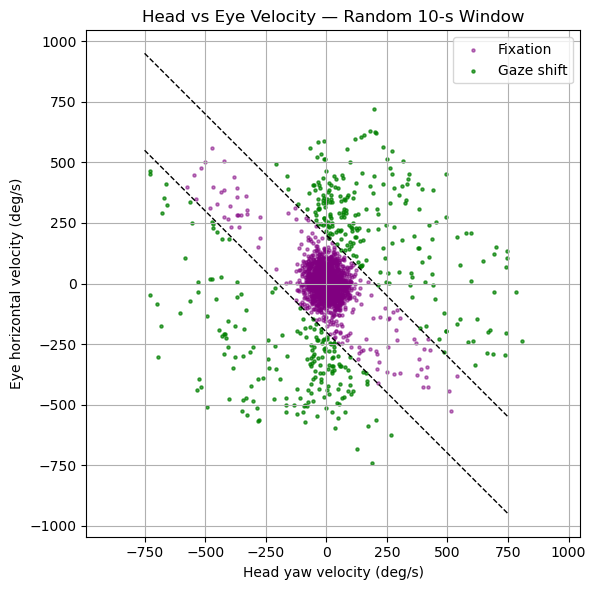

In [20]:
import numpy as np

# ==============================================================
# 1. Compute REAL fixation noise std
# ==============================================================

# fixation mask: |Vhead| + |Veye| < 200
fix_mask = (np.abs(Vhead) + np.abs(Veye)) < 200

# extract real fixation samples
fix_head = Vhead[fix_mask]
fix_eye  = Veye[fix_mask]

# compute noise std from real fixation
real_std_head = np.std(fix_head)
real_std_eye  = np.std(fix_eye)

print("=== Real fixation noise STD ===")
print(f"Head STD: {real_std_head:.4f}")
print(f"Eye  STD: {real_std_eye:.4f}")


# ==============================================================
# 2. Add Gaussian noise to simulated data
# ==============================================================

# Generate Gaussian noise using real fixation std
noise_head = np.random.normal(loc=0.0, scale=real_std_head, size=len(Vhead_sim))
noise_eye  = np.random.normal(loc=0.0, scale=real_std_eye,  size=len(Veye_sim))

# Apply noise
Vhead_sim_noisy = Vhead_sim + noise_head
Veye_sim_noisy  = Veye_sim  + noise_eye

print("\nNoise added to simulated data:")
print(f"Vhead_sim_noisy std: {np.std(Vhead_sim_noisy):.4f}")
print(f"Veye_sim_noisy  std: {np.std(Veye_sim_noisy):.4f}")



gaze_vel_rand = Vhead_sim_noisy + Veye_sim_noisy
is_shift = np.abs(gaze_vel_rand) > 200   # gaze shift threshold
is_fix = ~is_shift                       # fixation (complement)



# --- 🧮 Extract velocity pairs for each condition ---
head_fix = Vhead_sim_noisy[is_fix]
eye_fix = Veye_sim_noisy[is_fix]
head_shift = Vhead_sim_noisy[is_shift]
eye_shift =Veye_sim_noisy[is_shift]

# --- 📈 Calculate Pearson correlation (r) and p-value ---
r_fix, p_fix = pearsonr(head_fix, eye_fix)
r_shift, p_shift = pearsonr(head_shift, eye_shift)

# --- 🧾 Print results ---
print("Correlation results:")
print(f"Fixation: r = {r_fix:.3f}")
print(f"Gaze shift: r = {r_shift:.3f}")


# --- 🔷 Scatter plot: head vs eye velocity, colored by type ---
plt.figure(figsize=(6, 6))
plt.scatter(
    Vhead_sim_noisy[is_fix],
    Veye_sim_noisy[is_fix],
    s=5, color='purple', alpha=0.5, label='Fixation'
)
plt.scatter(
    Vhead_sim_noisy[is_shift],
    Veye_sim_noisy[is_shift],
    s=5, color='green', alpha=0.7, label='Gaze shift'
)

# Reference lines (±1 slope)
x = np.linspace(-750, 750, 200)
plt.plot(x, -200-x, 'k--', linewidth=1)
plt.plot(x, 200-x, 'k--', linewidth=1)

plt.xlabel('Head yaw velocity (deg/s)')
plt.ylabel('Eye horizontal velocity (deg/s)')
plt.title('Head vs Eye Velocity — Random 10-s Window')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


## Discussion

### Summary of Reproduction Attempt

Open the discussion section with a paragraph summarizing the primary result from the key analysis and assess whether you successfully reproduced it, partially reproduced it, or failed to reproduce it.  

Basically, this simulation method can reproduce the result of figure 6C in original paper. It shows negative relations in gaze fixation period. And postive correlation but not strong postive correlation in gaze shift events. Also, it has two kind of events that the figure 6D below shows.

Addtionally, this simulation data also keep the features of the interval that randomly chosen before. For example, the number of gaze shift events, the duration of each event and the peak velocity in each events. Moreover, its looks like simlar as the randomly distributed raw data.

So it is a good simulation method generally! Though it not totally reproduce the same figure of figure 6C. But it has the simliar finding to it. One reason for the difference is that we choose another interval different from figure 6C interval and we need to keep some raw fatures of our simulated data. Another reason is that the real-world data is really complex, the generation pipline can't explain all the varition that it has. It is normal for the simulation, we should prevent overfitting of our method so I tried many ways to make it not too complex.

If you choose another random seed, you can also get a good result. Howerver, your choosed interval should have a similar result to figure 6C. Some intervals don't have the gaze shift events.



### Commentary

Although I have given the simulated some random pulse to give varience and make them close to real data. One interesting point that we should also give our data some random gaussain nosie so we can get similar figure of figure 6C.But if we give them random gaussian noise, the generated data is not as smooth as raw data. The Gaussian noise we add to the simulation is an oversimplified approximation and does not capture the smooth and structured variability found in real biological signals.

I don't think it is a drawback of this model beacuse the variability of eye and head velocity really unpredictable, such a simple model or generation method is impoissible to explain such a huge biological neural network's variability. For my simulation model, it is important to show the key features and findings of research, not to reproduce the totally same data and expain all the varience. This algorithm now can only explain and simulate its basic functions that we care, but can't generate other variability correctly because this problem is really hard to slove. How the brain generates and organizes the variability in eye and head movements is a fundamentally complex problem that remains largely unresolved. But this question is really interesting.